In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 12}

plt.rc('font', **font)
plot_fs = 12

plt.rc('font', family='serif', serif='Times')
plt.rc('text', usetex=True)
plt.rc('xtick', labelsize=9)
plt.rc('ytick', labelsize=9)
plt.rc('axes', labelsize=10)
mpl.rcParams['lines.dashed_pattern'] = [2, 2]
mpl.rcParams['lines.linewidth'] = 1.0

import pathlib
cur_dir = pathlib.Path().cwd()
parent_dir = cur_dir.parent

import sys
print(sys.version)
sys.path.append('../')

from models.powertrain.bounded_powertrain import Bounded_powertrain
from models.kinematic.ideal_diff_drive import Ideal_diff_drive
from models.learning.blr_slip import SlipBayesianLinearRegression, FullBodySlipBayesianLinearRegression
from models.learning.blr_slip_acceleration import SlipAccelerationBayesianLinearRegression, FullBodySlipAccelerationBayesianLinearRegression
from models.kinematic.ICR_based import *
from models.kinematic.Perturbed_unicycle import *
from models.kinematic.enhanced_kinematic import *

from util.transform_algebra import *
from util.util_func import *
from data_utils.dataset_parser import *

from animate_time_constant import * 
import matplotlib.animation as animation
from matplotlib.backend_bases import KeyEvent
import tqdm

from NicolasSamson.script.extractors import * 
from NicolasSamson.script.acceleration_dataset_analyzer import * 

3.10.12 (main, Jul 19 2024, 11:05:56) [GCC 11.4.0]
3.10.12 (main, Jul 19 2024, 11:05:56) [GCC 11.4.0]


ModuleNotFoundError: No module named 'NicolasSamson.script.extractors'

In [16]:
surface_type = 'gravel'

if surface_type == 'gravel':
    path_2_dataset = '../NicolasSamson/drive_datasets/warthog/wheels/ice/ral2023/model_training_datasets/acceleration_dataset.pkl'
    global_save_path_ = '../NicolasSamson/analysis_why_metric/gravel'
    color_background = "lightgrey"

if surface_type == 'ice':
    path_2_dataset = '../NicolasSamson/drive_datasets/warthog/wheels/gravel/ral2023/model_training_datasets/acceleration_dataset.pkl'
    global_save_path_ = '../NicolasSamson/analysis_why_metric/ice'
    color_background = "lightblue"

df_acceleration = pd.read_pickle(path_2_dataset)

print_column_unique_column(df_acceleration)
print(df_acceleration.shape)




['body_vel_disturption_x' 'body_vel_disturption_y'
 'body_vel_disturption_yaw' 'calib_step' 'cmd_left' 'cmd_right'
 'gt_icp_pitch' 'gt_icp_roll' 'gt_icp_x' 'gt_icp_y' 'gt_icp_yaw'
 'gt_icp_z' 'icp_acceleration_x' 'icp_acceleration_y'
 'icp_acceleration_yaw' 'icp_corrected_interpolated_x'
 'icp_corrected_interpolated_y' 'icp_interpolated_x' 'icp_interpolated_y'
 'icp_interpolated_yaw' 'icp_omega' 'icp_pitch' 'icp_roll' 'icp_vel_x'
 'icp_vel_y' 'icp_vel_yaw' 'icp_vx' 'icp_vy' 'icp_x' 'icp_y' 'icp_yaw'
 'icp_z' 'idd_acceleration_x' 'idd_acceleration_y' 'idd_acceleration_yaw'
 'idd_vel_x' 'idd_vel_y' 'idd_vel_yaw' 'imu_acceleration_x'
 'imu_acceleration_y' 'imu_acceleration_z' 'imu_yaw' 'init_icp_pitch'
 'init_icp_roll' 'init_icp_x' 'init_icp_y' 'init_icp_yaw' 'init_icp_z'
 'left_wheel_vel' 'right_wheel_vel' 'steady_state_mask'
 'transitory_state_mask' 'transitory_vel_left' 'transitory_vel_right']
(591, 1458)


In [17]:
df_all_combined = pd.read_pickle("/home/nicolassamson/workspaces/norlab_WMRD/NicolasSamson/drive_datasets/all_terrain_diamond_shape_graph_data.pkl")

df_all_combined_gravel = df_all_combined.loc[df_all_combined["terrain"] == "gravel"]



(197, 19)


In [18]:

y_operation_pontverbose = True
rate = 0.05 #s
nb_timestamp = 120
verbose = True

name_column_cmd = 'cmd_l'
name_column_interest = "left_wheel_vel"
df_slip = df_acceleration

dico = compute_time_constant_wheel_and_body(df_slip,rate, nb_timestamp, verbose = False,produce_video_now = False,video_saving_path="")



#df_with_time_constant = pd.DataFrame(data=dico)
#new_df_diamond_shape = pd.concat((df_diamond_shape,df_2_add))

# df_2_add = pd.DataFrame.from_dict(dico_column_2_add)




0it [00:00, ?it/s]

/home/nicolassamson/workspaces/norlab_WMRD/NicolasSamson/../NicolasSamson/script/extractors.py:118: RuntimeWarning: overflow encountered in exp
  test = K*(1-np.exp(-(t-tau_d)/tau))
/home/nicolassamson/.pyenv/versions/data_analysis/lib/python3.10/site-packages/scipy/optimize/_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
4it [00:25,  6.27s/it]


In [19]:

list_keys = list(dico.keys())
kept_dico = {}
for key,value in dico.items():
    if "predictions_sum_abs" not in key:
        kept_dico[key] = value
        print(key, value.shape)

pd.DataFrame.from_dict(dico)

left_wheel_vel_gains (197,)
left_wheel_vel_time_constants (197,)
left_wheel_vel_time_delay (197,)
left_wheel_vel_time_constant_problematic_computation (197,)
left_wheel_vel_time_delay_problematic_computation (197,)
left_wheel_vel_valid_mask_tc (197,)
right_wheel_vel_gains (197,)
right_wheel_vel_time_constants (197,)
right_wheel_vel_time_delay (197,)
right_wheel_vel_time_constant_problematic_computation (197,)
right_wheel_vel_time_delay_problematic_computation (197,)
right_wheel_vel_valid_mask_tc (197,)
icp_vel_x_gains (197,)
icp_vel_x_time_constants (197,)
icp_vel_x_time_delay (197,)
icp_vel_x_time_constant_problematic_computation (197,)
icp_vel_x_time_delay_problematic_computation (197,)
icp_vel_x_valid_mask_tc (197,)
icp_vel_yaw_gains (197,)
icp_vel_yaw_time_constants (197,)
icp_vel_yaw_time_delay (197,)
icp_vel_yaw_time_constant_problematic_computation (197,)
icp_vel_yaw_time_delay_problematic_computation (197,)
icp_vel_yaw_valid_mask_tc (197,)


,left_wheel_vel_gains,left_wheel_vel_time_constants,left_wheel_vel_time_delay,left_wheel_vel_time_constant_problematic_computation,left_wheel_vel_time_delay_problematic_computation,left_wheel_vel_valid_mask_tc,right_wheel_vel_gains,right_wheel_vel_time_constants,right_wheel_vel_time_delay,right_wheel_vel_time_constant_problematic_computation,...,icp_vel_x_time_delay,icp_vel_x_time_constant_problematic_computation,icp_vel_x_time_delay_problematic_computation,icp_vel_x_valid_mask_tc,icp_vel_yaw_gains,icp_vel_yaw_time_constants,icp_vel_yaw_time_delay,icp_vel_yaw_time_constant_problematic_computation,icp_vel_yaw_time_delay_problematic_computation,icp_vel_yaw_valid_mask_tc
0,7.283362e-01,0.694140,0.207113,False,False,False,7.027865e-01,0.746385,0.250022,False,...,0.553484,False,False,False,0.424362,1.011315,0.244610,False,False,False
1,9.888222e-01,0.597010,0.159799,False,False,False,1.003190e+00,0.153354,0.048017,False,...,0.098612,False,False,False,0.681132,2.373675,0.100691,False,False,False
2,8.953370e-01,0.584491,0.167185,False,False,False,-6.334533e-01,0.122569,0.050000,False,...,0.237570,False,False,False,0.423029,1.147889,0.371556,False,False,False
3,4.769658e-01,0.231182,0.070337,False,False,False,3.285681e+01,0.217004,0.049999,False,...,0.001000,False,False,False,-0.056363,1.832883,0.178549,False,False,False
4,1.016624e+00,0.401148,0.111414,False,False,False,1.516656e+00,0.594688,0.149416,False,...,0.117373,False,False,False,1.756303,0.668512,0.238096,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,8.870557e-01,0.612053,0.198865,False,False,False,9.570846e-01,0.428598,0.094323,False,...,0.117468,False,False,False,0.880334,0.500961,0.154756,False,False,False
193,1.022094e+00,0.560058,0.100001,False,False,False,9.587379e-01,0.363646,0.150437,False,...,1.978743,False,False,False,0.105259,2.775468,0.122622,False,False,False
194,-3.552816e-09,1.050530,0.110185,False,False,False,-3.552816e-09,1.050530,0.110185,False,...,0.058123,False,False,False,-0.000586,1.049350,0.001000,False,False,False
195,-3.552816e-09,1.050530,0.110185,False,False,False,-3.552816e-09,1.050530,0.110185,False,...,0.110394,False,False,False,0.001605,1.050362,0.110016,False,False,False


In [21]:
y_operation_pontverbose = True
rate = 0.05 #s
nb_timestamp = 120
verbose = True



left_wheel_vel = column_type_extractor(df_acceleration, 'left_wheel_vel',verbose=verbose)
right_wheel_vel = column_type_extractor(df_acceleration, 'right_wheel_vel',verbose=verbose)
icp_vel_x = column_type_extractor(df_acceleration, 'icp_vel_x',verbose=verbose)
icp_vel_yaw = column_type_extractor(df_acceleration, 'icp_vel_yaw',verbose=verbose)
body_vel_icp = np.vstack((icp_vel_x,icp_vel_yaw))


raw_icp_vel_x = column_type_extractor(df_acceleration, 'raw_icp_vel_x',verbose=False)
raw_icp_vel_yaw = column_type_extractor(df_acceleration, 'raw_icp_vel_yaw',verbose=False)
print_column_unique_column(df_acceleration)
column_to_reshape = [left_wheel_vel,right_wheel_vel,
                    icp_vel_x,icp_vel_yaw, body_vel_icp,
                    raw_icp_vel_x,raw_icp_vel_yaw]



for i in range(len(column_to_reshape)):
    column_to_reshape[i] = reshape_into_6sec_windows(column_to_reshape[i], n_window=3)
    


left_wheel_vel,right_wheel_vel, icp_vel_x,icp_vel_yaw, body_vel_icp,raw_icp_vel_x,raw_icp_vel_yaw = column_to_reshape



time_axis = create_time_axe(rate,nb_timestamp)



________left_wheel_vel________
The column type: left_wheel_vel
The resulting dataframe_shape: (591, 40)
Number of calibrating steps:591
Number of measurement by step: 40
Maximum 12.941616403537953
Minimum -13.041972835527627
______________________________
________right_wheel_vel________
The column type: right_wheel_vel
The resulting dataframe_shape: (591, 40)
Number of calibrating steps:591
Number of measurement by step: 40
Maximum 12.919799787888024
Minimum -12.705996954518719
_______________________________
________icp_vel_x________
The column type: icp_vel_x
The resulting dataframe_shape: (591, 40)
Number of calibrating steps:591
Number of measurement by step: 40
Maximum 2.711354718615302
Minimum -3.478417039510205
_________________________
________icp_vel_yaw________
The column type: icp_vel_yaw
The resulting dataframe_shape: (591, 40)
Number of calibrating steps:591
Number of measurement by step: 40
Maximum 2.755186351506815
Minimum -3.3384444392036343
___________________________


In [22]:
# compute the cmds 
cmd_left_all = column_type_extractor(df_acceleration, 'cmd_l',verbose=False)
cmd_right_all = column_type_extractor(df_acceleration, 'cmd_r',verbose=False)

# Compute the body vel 
cmd_body_vel_yaw_all = []
cmd_body_vel_x_all = []

n_step = cmd_left_all.shape[0] 
horizon_length = cmd_left_all.shape[1]
total_info = n_step * horizon_length
final_shape = ( total_info//(horizon_length *3), horizon_length *3)

for calib_step in range(n_step):
    for i in range(horizon_length): 
        cmd_vel_wheel_i = np.array([cmd_left_all[calib_step,i],cmd_right_all[calib_step,i]])
    
        body_vel_i = compute_body_vel_IDD(cmd_vel_wheel_i , robot='warthog-wheel')
        cmd_body_vel_yaw_all.append(body_vel_i[1])
        cmd_body_vel_x_all.append(body_vel_i[0])

# The computed body vel reshape 
cmd_body_vel_x_all = np.array(cmd_body_vel_x_all).reshape(final_shape)
cmd_body_vel_yaw_all = np.array(cmd_body_vel_yaw_all).reshape(final_shape)
cmd_left_all_reshape = cmd_left_all.reshape(final_shape)
cmd_right_all_reshape = cmd_right_all.reshape(final_shape)



In [23]:
# Calculate the y normalized and centered. 
normalized_left_wheel,normalized_cmd_left_all_reshape = normalizer_2d_array(left_wheel_vel,cmd_left_all_reshape)
normalized_right_wheel_vel,normalized_cmd_right_all_reshape = normalizer_2d_array(right_wheel_vel,cmd_right_all_reshape)
normalized_icp_vel_x, noramilzed_cmd_body_vel_x_all = normalizer_2d_array(icp_vel_x, cmd_body_vel_x_all)
normalized_icp_vel_yaw, normalized_cmd_body_vel_yaw_all = normalizer_2d_array(icp_vel_yaw, cmd_body_vel_yaw_all)




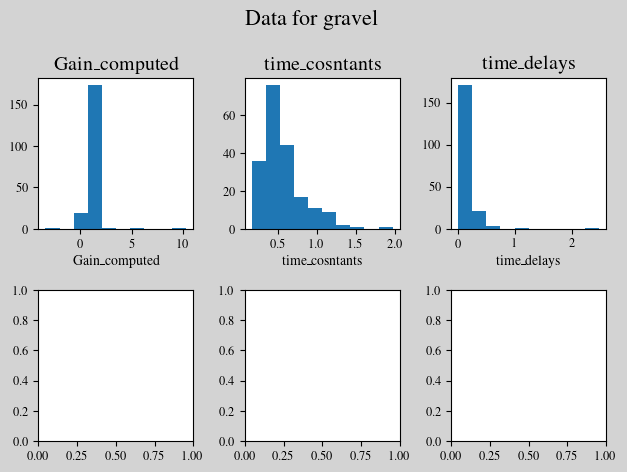

In [27]:
fig, axs = plt.subplots(2,3)


axs[0][0].hist(dico[name_column_interest+"_gains"],label="gain_computed")


mask_delay = np.where(dico[name_column_interest+"_time_delay_problematic_computation"]==True,False,True)

time_delay = dico[name_column_interest+"_time_delay"]#[mask_delay]
axs[0][2].hist(time_delay,label="time_delay")


mask_time_constant = np.where(dico[name_column_interest+"_time_constant_problematic_computation"]==True,False,True)

time_constant = dico[name_column_interest+"_time_constants"]#[mask_time_constant]

axs[0][1].hist(time_constant,label="time_constants")


axs[0][0].set_title("Gain_computed")
axs[0][1].set_title("time_cosntants")
axs[0][2].set_title("time_delays")

axs[0][0].set_xlabel("Gain_computed")
axs[0][1].set_xlabel("time_cosntants")
axs[0][2].set_xlabel("time_delays")



y_min = 0
y_max = 3
#axs[0][0].set_xlim((y_min,y_max))
#axs[0][1].set_xlim((y_min,y_max))
#axs[0][2].set_xlim((y_min,y_max))
#axs[1][1].set_ylim((y_min,y_max))
fig.suptitle(f"Data for {surface_type}",fontsize=16)

fig.patch.set_facecolor(color_background)

fig.tight_layout()


In [25]:
# Computed te operation point and the steps 
operation_point_left_wheel,steps_cmd_left_all_reshape = compute_operation_points_and_step(left_wheel_vel,cmd_left_all_reshape)
operation_point_right_wheel_vel,steps_cmd_right_all_reshape = compute_operation_points_and_step(right_wheel_vel,cmd_right_all_reshape)
operation_point_icp_vel_x, steps_cmd_body_vel_x_all = compute_operation_points_and_step(icp_vel_x, cmd_body_vel_x_all)
operation_point_icp_vel_yaw, steps_cmd_body_vel_yaw_all = compute_operation_points_and_step(icp_vel_yaw, cmd_body_vel_yaw_all)



In [26]:
first_model = FirstOrderModelWithDelay(1,1,rate)
step_y_left_wheeleft_wheel_vell_vel_centered = left_wheel_vel-operation_point_left_wheel

gains_computed, time_constants_computed, time_delay_computed,predictions = first_model.train_all_calib_state(time_axis,steps_cmd_left_all_reshape,step_y_left_wheeleft_wheel_vell_vel_centered,operation_point_left_wheel)

print(predictions)

TypeError: FirstOrderModelWithDelay.train_all_calib_state() missing 1 required positional argument: 'max_time_bounds'

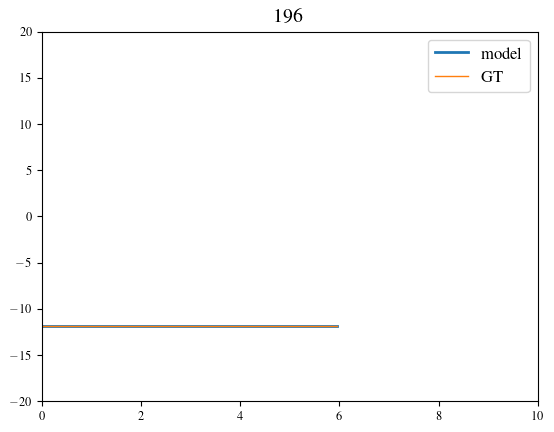

In [14]:

# Initialize data
data = {'x': [], 'y': []}

# Create a figure and axis
fig, ax = plt.subplots()
line, = ax.plot([], [], lw=2,label ="model")
line2, = ax.plot([],[],label = "GT")

# Set up the plot limits
ax.set_xlim(0, 10)
ax.set_ylim(-20, 20)
ax.legend()

# Initialize animation data
def init():
    line.set_data([], [])
    return line,

# Update the line data
def update(anim_i):
    line.set_data(time_axis, predictions[anim_i,:])
    line2.set_data(time_axis, left_wheel_vel[anim_i,:])
    #ax.set_title(f"time constant {time_constants_computed[anim_i]} \n time_delay {time_delay_computed} \n gains {gains_computed} ")
    ax.set_title(f"{anim_i}")
    return line,line2

# Function to handle key presses

# Create the animation
ani = animation.FuncAnimation(
    fig,
    update,
    frames=range(10),
    init_func=init,
    blit=True,
    interval=1000  # Update interval in milliseconds
)

ani = animation.FuncAnimation(fig, update, init_func=init, frames=predictions.shape[0], interval=1000, blit=True)

# Save the animation as a video
ani.save('sine_wave_animation.mp4', writer='ffmpeg')


In [15]:
print(np.median(gains_computed))
print(np.median(time_constants_computed))
print(np.median(time_delay_computed))



0.9710291346626466
0.4901583451982429
0.14443099568847462


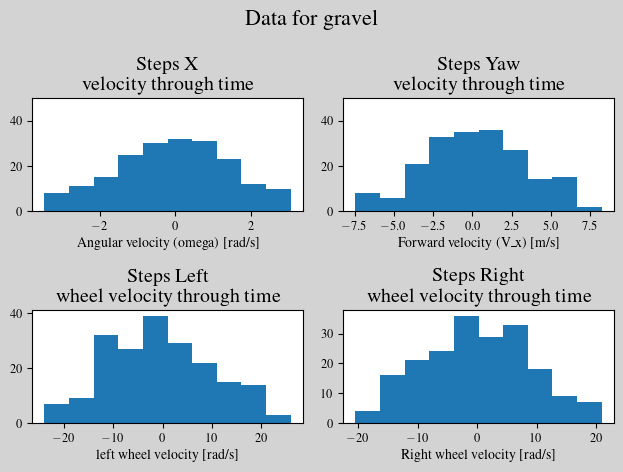

In [16]:



fig, axs = plt.subplots(2,2)


axs[0][0].hist(steps_cmd_body_vel_x_all,label="ICP_raw")
axs[0][1].hist(steps_cmd_body_vel_yaw_all,label="ICP_raw")


axs[1][1].hist(steps_cmd_right_all_reshape,label="wheel odometry")
axs[1][0].hist(steps_cmd_left_all_reshape,label="wheel odometry")

axs[0][0].set_title("Steps X \n velocity through time")
axs[0][1].set_title("Steps Yaw \n velocity through time")
axs[1][0].set_title("Steps Left \n wheel velocity through time")
axs[1][1].set_title("Steps Right \n wheel velocity through time")

axs[0][0].set_xlabel("Angular velocity (omega) [rad/s]")
axs[0][1].set_xlabel("Forward velocity (V_x) [m/s]")

axs[1][0].set_xlabel("left wheel velocity [rad/s]")
axs[1][1].set_xlabel("Right wheel velocity [rad/s]")


y_min = 0
y_max = 50
axs[0][0].set_ylim((y_min,y_max))
axs[0][1].set_ylim((y_min,y_max))
#axs[1][0].set_ylim((y_min,y_max))
#axs[1][1].set_ylim((y_min,y_max))
fig.suptitle(f"Data for {surface_type}",fontsize=16)

fig.patch.set_facecolor(color_background)

fig.tight_layout()


